<a href="https://colab.research.google.com/github/Kanabee/Bangkok_Public_Issue_Report_Analysis/blob/main/Bangkok_Public_Issue_Analysis_edit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bangkok Public Issue Report Analysis

## NLP and Exploratory Data Analysis of Traffy Fondue Reports

This project analyzes public issue reports submitted in Bangkok to identify the most common urban problems, compare issue patterns across districts, and explore recurring topics in Thai-language comments.

**Business question:** How can complaint data be converted into actionable information that helps city teams prioritize problems and allocate resources?

**Tools:** Python, Pandas, Matplotlib, Seaborn, PyThaiNLP, Scikit-learn, and WordCloud

## Project objectives

1. Inspect and clean public issue-report data.
2. Measure reporting volume across Bangkok districts.
3. Classify Thai comments into practical issue categories using transparent keyword rules.
4. Compare both issue volume and issue rate across districts.
5. Discover additional themes with unsupervised text clustering.
6. Translate analytical results into operational recommendations.

## Workflow

`Data collection → Data validation → Data cleaning → Exploratory analysis → Thai text classification → District comparison → Topic discovery → Business insights`

## 1. Environment setup

In [1]:
%pip -q install pythainlp wordcloud

import re
import warnings
from collections import Counter
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from pythainlp.tokenize import word_tokenize
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    silhouette_score,
    precision_score,
    recall_score,
    f1_score,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 71.9 MB/s eta 0:00:00


In [2]:
# ตั้งค่าฟอนต์ภาษาไทยสำหรับ Matplotlib

font_url = "https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf"
font_path = "/content/thsarabunnew-webfont.ttf"

urlretrieve(font_url, font_path)

# เพิ่มฟอนต์เข้า Matplotlib
fm.fontManager.addfont(font_path)

thai_font = fm.FontProperties(fname=font_path)
thai_font_name = thai_font.get_name()

plt.rcParams["font.family"] = thai_font_name
plt.rcParams["font.size"] = 16
plt.rcParams["axes.unicode_minus"] = False

print("Thai font:", thai_font_name)

Thai font: TH Sarabun New


## 2. Data collection

In [3]:
DATA_URL = (
    "https://docs.google.com/spreadsheets/d/e/"
    "2PACX-1vT_pDMw6gxubdVtOQele40Wfzfk2XtmryfGfC4kLjwH4oI-uO1jfBGcEmNJlGkLUROa3dQ0iXjdZnOc/"
    "pub?gid=1020716921&single=true&output=csv"
)

raw = pd.read_csv(DATA_URL)
data = raw.copy()

print(f"Rows: {data.shape[0]:,}")
print(f"Columns: {data.shape[1]}")
display(data.head())

Rows: 20,730
Columns: 13


,id,type,comment,ticket_id,coords,photo,after_photo,address,district,subdistrict,province,timestamp,state
0,64202,อื่นๆ,กันที่จอดรถ,2022-GRY4C9,"[100.684183, 13.920973]",https://storage.googleapis.com/traffy_public_b...,NaN,48/35 ถ. สายไหม แขวง สายไหม เขตสายไหม กรุงเทพม...,สายไหม,สายไหม,กรุงเทพมหานคร,2022-06-12 04:01:00.035653+00,รอรับเรื่อง
1,64201,น้ำท่วม,ผักตบชวาขึ้นในคลองจำนวนมาก ทำให้การระบายน้ำไม่...,2022-A66BE2,"[100.493724010885, 13.7899584498057]",https://storage.googleapis.com/traffy_public_b...,NaN,200 สิรินธร แขวง บางพลัด เขตบางพลัด กรุงเทพมหา...,บางพลัด,บางพลัด,กรุงเทพมหานคร,2022-06-12 03:59:50.588741+00,ส่งเรื่องแล้ว
2,64199,อื่นๆ,1. รถหามเร่ รถขายของบนถนน,2022-4NNADE,"[100.52675306797, 13.7123723956191]",https://storage.googleapis.com/traffy_public_b...,NaN,เลขที่ 127/46 หมู่ - หมู่บ้าน - ซอย จันทน์18/7...,สาทร,ทุ่งวัดดอน,กรุงเทพมหานคร,2022-06-12 03:58:43.913163+00,รอรับเรื่อง
3,64198,อื่นๆ,สน. พหลโยธิน เค้าจะรื้อถอนไหมครับ เพราะทางเท้า...,2022-D328VH,"[100.5836, 13.800689]",https://storage.googleapis.com/traffy_public_b...,NaN,1429 ซอย ลาดพร้าว 41 แยก 6-4 แขวง สามเสนนอก เข...,ห้วยขวาง,สามเสนนอก,กรุงเทพมหานคร,2022-06-12 03:58:27.202716+00,รอรับเรื่อง
4,64197,อื่นๆ,จอดส่งของ,2022-EAP43H,"[100.684183, 13.920973]",https://storage.googleapis.com/traffy_public_b...,NaN,48/35 ถ. สายไหม แขวง สายไหม เขตสายไหม กรุงเทพม...,สายไหม,สายไหม,กรุงเทพมหานคร,2022-06-12 03:58:19.000336+00,รอรับเรื่อง


## 3. Data validation and cleaning

The validation step checks schema, data types, missing values, and duplicated records. Text and location fields are standardized before analysis. Invalid timestamps are converted to missing values instead of stopping the workflow.

In [4]:
display(data.info())

quality_report = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing_count": data.isna().sum(),
    "missing_percent": (data.isna().mean() * 100).round(2),
    "unique_values": data.nunique(dropna=True),
}).sort_values("missing_percent", ascending=False)

display(quality_report)
print(f"Duplicated rows: {data.duplicated().sum():,}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20730 entries, 0 to 20729
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           20730 non-null  int64 
 1   type         20730 non-null  object
 2   comment      20730 non-null  object
 3   ticket_id    20725 non-null  object
 4   coords       20730 non-null  object
 5   photo        20730 non-null  object
 6   after_photo  2708 non-null   object
 7   address      20730 non-null  object
 8   district     20728 non-null  object
 9   subdistrict  20730 non-null  object
 10  province     20730 non-null  object
 11  timestamp    20730 non-null  object
 12  state        20730 non-null  object
dtypes: int64(1), object(12)
memory usage: 2.1+ MB


None

,dtype,missing_count,missing_percent,unique_values
after_photo,object,18022,86.94,2708
ticket_id,object,5,0.02,20725
district,object,2,0.01,65
id,int64,0,0.00,20730
type,object,0,0.00,7
coords,object,0,0.00,18290
comment,object,0,0.00,17362
photo,object,0,0.00,20730
address,object,0,0.00,14574
subdistrict,object,0,0.00,202


Duplicated rows: 0


In [5]:
required_columns = {"comment", "district", "subdistrict", "timestamp", "state"}
missing_columns = required_columns.difference(data.columns)
if missing_columns:
    raise ValueError(f"Required columns are missing: {sorted(missing_columns)}")

data = data.drop_duplicates().copy()

text_columns = ["comment", "district", "subdistrict", "province", "state", "type"]
for column in [c for c in text_columns if c in data.columns]:
    data[column] = data[column].fillna("").astype(str).str.strip()

data["timestamp"] = pd.to_datetime(data["timestamp"], errors="coerce", utc=True)
data["date"] = data["timestamp"].dt.date
data["month"] = data["timestamp"].dt.to_period("M").astype(str)

# Remove records without usable text for NLP analysis.
analysis_data = data.loc[data["comment"].str.len() > 0].copy()

print(f"Rows after cleaning: {analysis_data.shape[0]:,}")
print(f"Rows removed: {raw.shape[0] - analysis_data.shape[0]:,}")

# Identical complaint text submitted more than once.
# drop_duplicates() above cannot catch these: each row carries a distinct id
# and timestamp, so the records differ even when the report does not.
repeat_text = analysis_data["comment"].duplicated().sum()
print(
    f"Reports whose comment text has appeared before: {repeat_text:,} "
    f"({repeat_text / len(analysis_data):.1%})"
)
print(
    "Kept rather than removed: repeated short text such as a parking "
    "complaint is often a genuinely separate incident. Flagged here so the "
    "counts below are read with it in mind."
)

Rows after cleaning: 20,730
Rows removed: 0
Reports whose comment text has appeared before: 3,368 (16.2%)
Kept rather than removed: repeated short text such as a parking complaint is often a genuinely separate incident. Flagged here so the counts below are read with it in mind.


## 4. Exploratory data analysis

In [6]:
summary = pd.Series({
    "Total reports": len(analysis_data),
    "Districts": analysis_data["district"].replace("", np.nan).nunique(),
    "Subdistricts": analysis_data["subdistrict"].replace("", np.nan).nunique(),
    "Start date": analysis_data["timestamp"].min(),
    "End date": analysis_data["timestamp"].max(),
})
display(summary.to_frame("value"))

,value
Total reports,20730
Districts,65
Subdistricts,202
Start date,2022-05-25 17:44:19.135957+00:00
End date,2022-06-12 04:01:00.035653+00:00


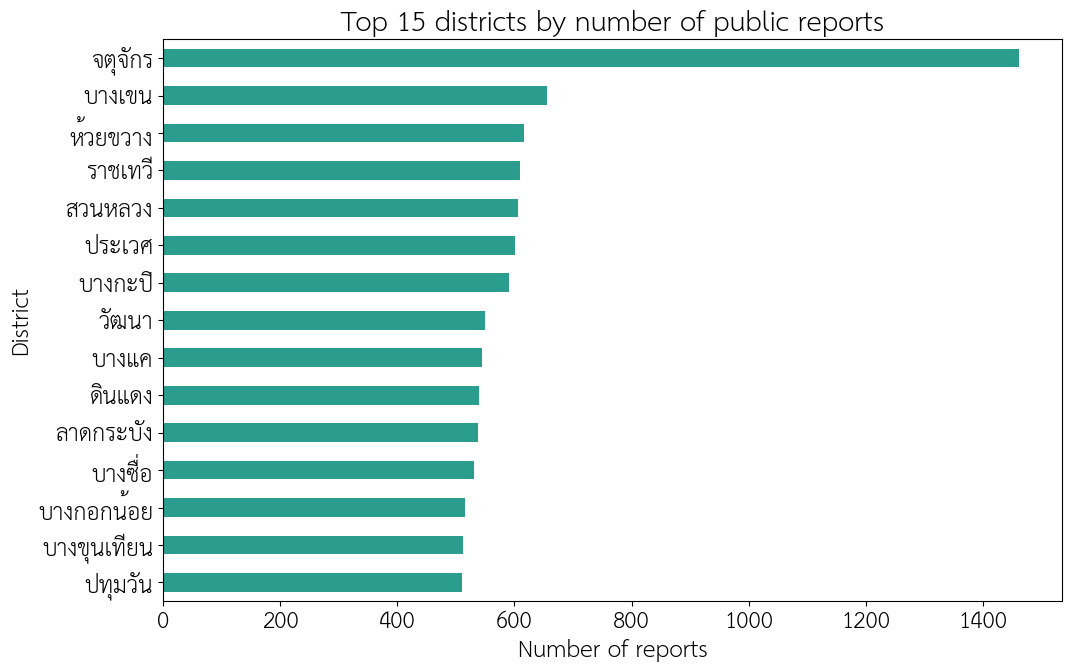

In [7]:
district_counts = (
    analysis_data.loc[analysis_data["district"] != "", "district"]
    .value_counts()
    .head(15)
    .sort_values()
)

ax = district_counts.plot(kind="barh", figsize=(11, 7), color="#2A9D8F")
ax.set_title("Top 15 districts by number of public reports")
ax.set_xlabel("Number of reports")
ax.set_ylabel("District")
plt.tight_layout()
plt.show()

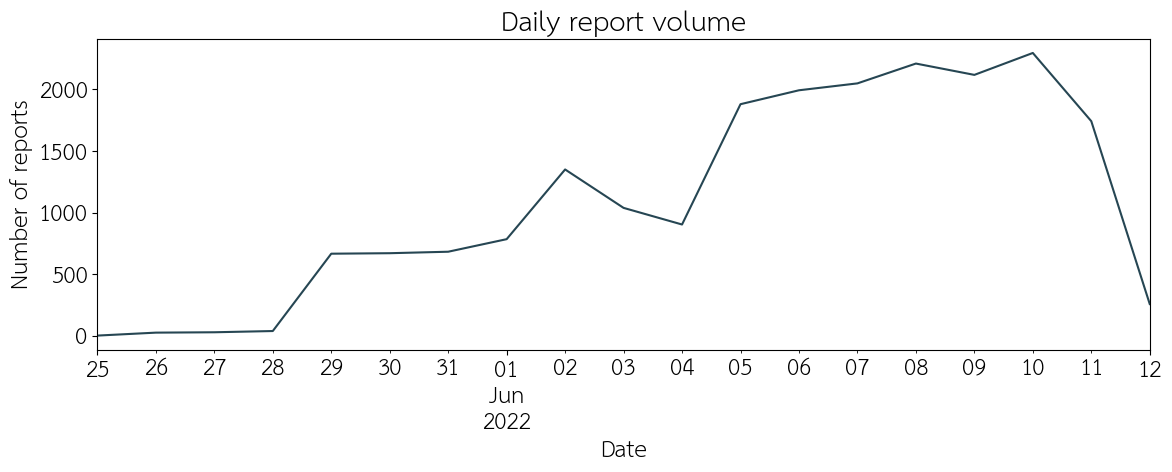

In [8]:
if analysis_data["timestamp"].notna().any():
    daily_reports = analysis_data.set_index("timestamp").resample("D").size()
    ax = daily_reports.plot(figsize=(12, 5), color="#264653")
    ax.set_title("Daily report volume")
    ax.set_xlabel("Date")
    ax.set_ylabel("Number of reports")
    plt.tight_layout()
    plt.show()

## 5. Rule-based Thai issue classification

A keyword dictionary is used to create explainable issue flags. A report may belong to more than one category because real complaints often mention multiple problems. This approach is easy for non-technical stakeholders to review and update.

In [9]:
ISSUE_KEYWORDS = {
    "น้ำท่วม/ระบายน้ำ": ["น้ำท่วม", "น้ำขัง", "ระบายน้ำ", "ท่ออุดตัน", "ฝนตก"],
    "แสงสว่าง": ["มืด", "ไฟดับ", "ไฟส่องสว่าง", "เปลี่ยว"],
    "จราจร": ["รถติด", "จราจร", "การจราจร", "ติดขัด"],
    "ทางข้าม": ["ทางม้าลาย", "ม้าลาย", "ข้ามถนน"],
    "ขยะ/กลิ่น/น้ำเสีย": ["สกปรก", "ขยะ", "เหม็น", "กลิ่น", "น้ำเสีย"],
    "สัตว์": ["แมว", "สุนัข", "หมา", "จรจัด", "สัตว์"],
    "ทางเท้า": ["ทางเดิน", "ทางเท้า", "ฟุตบาท", "กีดขวาง", "จอดรถบนทางเท้า"],
    "ถนน": ["หลุม", "ถนนพัง", "ถนนชำรุด", "ถนนขรุขระ", "ป้ายบอกทาง"],
    "สายไฟ/ความเป็นระเบียบ": ["สายไฟ", "ไม่เป็นระเบียบ", "สายสื่อสาร"],
    "ต้นไม้": ["ต้นไม้", "กิ่งไม้"],
    "ความปลอดภัย": ["ไม่ปลอดภัย", "อันตราย", "เสี่ยงอุบัติเหตุ"],
}


def add_issue_flags(df, text_column="comment"):
    result = df.copy()
    text = result[text_column].fillna("").astype(str)
    for issue, keywords in ISSUE_KEYWORDS.items():
        pattern = "|".join(re.escape(word) for word in keywords)
        result[issue] = text.str.contains(pattern, case=False, regex=True).astype(int)
    return result


classified = add_issue_flags(analysis_data)
issue_columns = list(ISSUE_KEYWORDS)
classified["classified_issue_count"] = classified[issue_columns].sum(axis=1)

coverage = (classified["classified_issue_count"] > 0).mean() * 100
print(f"Reports matched to at least one issue category: {coverage:.2f}%")

Reports matched to at least one issue category: 64.46%


,report_count,share_percent
ทางเท้า,4351.0,20.99
จราจร,2257.0,10.89
ขยะ/กลิ่น/น้ำเสีย,2110.0,10.18
น้ำท่วม/ระบายน้ำ,2091.0,10.09
ความปลอดภัย,1717.0,8.28
แสงสว่าง,1560.0,7.53
ถนน,1514.0,7.30
สายไฟ/ความเป็นระเบียบ,917.0,4.42
สัตว์,858.0,4.14
ทางข้าม,750.0,3.62


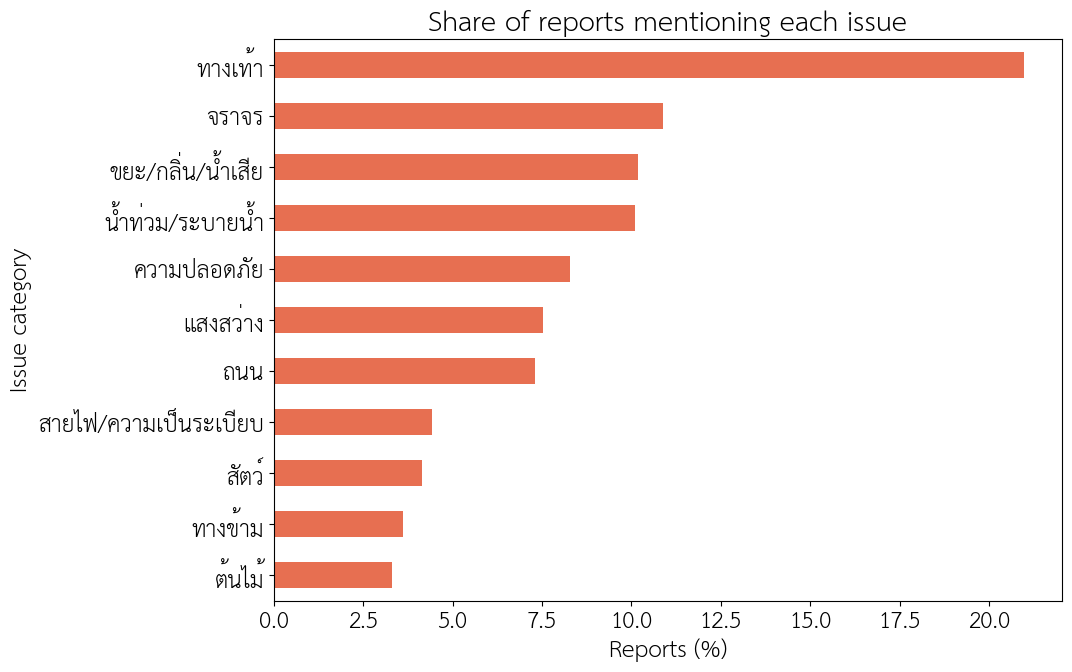

In [10]:
issue_summary = (
    classified[issue_columns]
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "report_count", "mean": "share"})
)
issue_summary["share_percent"] = issue_summary["share"] * 100
issue_summary = issue_summary.sort_values("report_count", ascending=False)

display(issue_summary[["report_count", "share_percent"]].round(2))

ax = issue_summary.sort_values("share_percent")["share_percent"].plot(
    kind="barh", figsize=(11, 7), color="#E76F51"
)
ax.set_title("Share of reports mentioning each issue")
ax.set_xlabel("Reports (%)")
ax.set_ylabel("Issue category")
plt.tight_layout()
plt.show()

## 5b. Validating the keyword rules against platform labels

The dataset carries a `type` column — the category Traffy itself assigned to
each report. That makes it possible to measure the keyword rules rather than
just trust them.

This is not a perfect ground truth: platform categories are single-label while
the rules are multi-label, and the two taxonomies were designed independently.
It is, however, an independent opinion about the same reports, and checking
against it is cheap.

In [11]:
# Platform categories present in the data
type_counts = analysis_data["type"].value_counts()
display(type_counts.to_frame("reports"))
print(f"Distinct platform categories: {analysis_data['type'].nunique()}")

,reports
type,
อื่นๆ,15846
ความปลอดภัย,1382
ทางเท้า,1233
จราจร,1230
น้ำท่วม,399
ขยะ,384
เสนอแนะ,256


Distinct platform categories: 7


In [12]:
# Map each keyword rule to the platform category it should correspond to.
# Rules with no counterpart are left unmapped and reported separately.
RULE_TO_TYPE = {
    "น้ำท่วม/ระบายน้ำ": "น้ำท่วม",
    "ถนน": "ถนน",
    "ทางเท้า": "ทางเท้า",
    "แสงสว่าง": "แสงสว่าง",
    "ความปลอดภัย": "ความปลอดภัย",
    "ขยะ/กลิ่น/น้ำเสีย": "ความสะอาด",
    "จราจร": "จราจร",
}

# Keep only mappings whose target actually exists in this extract
available = set(analysis_data["type"].unique())
RULE_TO_TYPE = {r: t for r, t in RULE_TO_TYPE.items() if t in available}

unmapped = [r for r in issue_columns if r not in RULE_TO_TYPE]
print("Validated rules:", list(RULE_TO_TYPE))
print("Rules with no platform counterpart:", unmapped)
print(
    "\nUnmapped rules are not wrong — they capture issues the platform "
    "taxonomy does not separate. They simply cannot be scored this way."
)

Validated rules: ['น้ำท่วม/ระบายน้ำ', 'ทางเท้า', 'ความปลอดภัย', 'จราจร']
Rules with no platform counterpart: ['แสงสว่าง', 'ทางข้าม', 'ขยะ/กลิ่น/น้ำเสีย', 'สัตว์', 'ถนน', 'สายไฟ/ความเป็นระเบียบ', 'ต้นไม้']

Unmapped rules are not wrong — they capture issues the platform taxonomy does not separate. They simply cannot be scored this way.


In [13]:
rows = []
for rule, platform_type in RULE_TO_TYPE.items():
    y_true = (classified["type"] == platform_type).astype(int)
    y_pred = classified[rule]
    rows.append({
        "rule": rule,
        "platform type": platform_type,
        "platform count": int(y_true.sum()),
        "rule count": int(y_pred.sum()),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    })

validation_table = (
    pd.DataFrame(rows).set_index("rule").sort_values("f1", ascending=False)
)
display(validation_table.round(3))

print(
    "Precision: of the reports this rule flags, the share the platform also "
    "placed in the matching category.\n"
    "Recall: of the reports the platform placed there, the share this rule "
    "caught."
)

,platform type,platform count,rule count,precision,recall,f1
rule,,,,,,
ทางเท้า,ทางเท้า,1233,4351,0.201,0.710,0.313
จราจร,จราจร,1230,2257,0.240,0.440,0.310
น้ำท่วม/ระบายน้ำ,น้ำท่วม,399,2091,0.157,0.825,0.264
ความปลอดภัย,ความปลอดภัย,1382,1717,0.150,0.186,0.166


Precision: of the reports this rule flags, the share the platform also placed in the matching category.
Recall: of the reports the platform placed there, the share this rule caught.


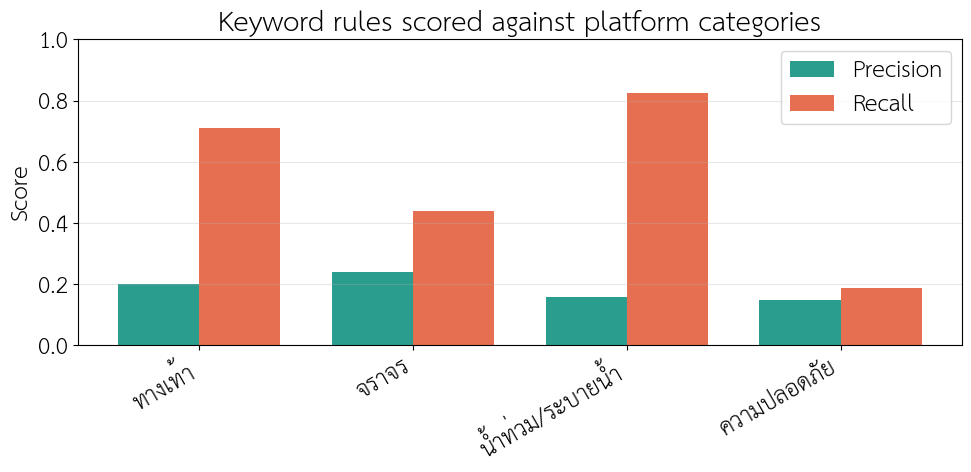

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
idx = np.arange(len(validation_table))
w = 0.38
ax.bar(idx - w/2, validation_table["precision"], w, label="Precision",
       color="#2A9D8F")
ax.bar(idx + w/2, validation_table["recall"], w, label="Recall",
       color="#E76F51")
ax.set_xticks(idx)
ax.set_xticklabels(validation_table.index, rotation=30, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Keyword rules scored against platform categories")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Reading these numbers

High recall with low precision means the rule fires on reports the platform
filed elsewhere. That is expected for multi-label rules — a comment can mention
a flooded footpath and be filed once — so low precision here is not
automatically an error.

Low recall is the more actionable signal: it points to vocabulary the keyword
list is missing, and the clustering section below is where those missing terms
can be found.

## 6. District-level comparison

Raw complaint counts may favor districts with more residents or more active reporters. Therefore, this section reports both:

- **Issue volume:** number of matched reports.
- **Issue rate:** percentage of all reports in a district that mention the issue.

Districts with very few reports are excluded from rate rankings to reduce unstable comparisons.

In [15]:
MIN_DISTRICT_REPORTS = 100

district_total = classified.groupby("district").size().rename("total_reports")
eligible_districts = district_total[district_total >= MIN_DISTRICT_REPORTS].index

district_issue_count = classified.groupby("district")[issue_columns].sum()
district_issue_rate = district_issue_count.div(district_total, axis=0) * 100
district_issue_rate = district_issue_rate.loc[eligible_districts]

selected_issue = issue_summary.index[0]
comparison = pd.DataFrame({
    "issue_reports": district_issue_count.loc[eligible_districts, selected_issue],
    "issue_rate_percent": district_issue_rate[selected_issue],
    "all_reports": district_total.loc[eligible_districts],
}).sort_values("issue_rate_percent", ascending=False)

print(f"District comparison for: {selected_issue}")
display(comparison.head(10).round(2))

District comparison for: ทางเท้า


,issue_reports,issue_rate_percent,all_reports
district,,,
ป้อมปราบศัตรูพ่าย,109,42.58,256
พระนคร,93,32.98,282
วัฒนา,166,30.18,550
บางนา,119,29.82,399
ปทุมวัน,144,28.24,510
จตุจักร,410,28.04,1462
จอมทอง,125,27.41,456
บางพลัด,127,27.14,468
คลองเตย,122,27.05,451


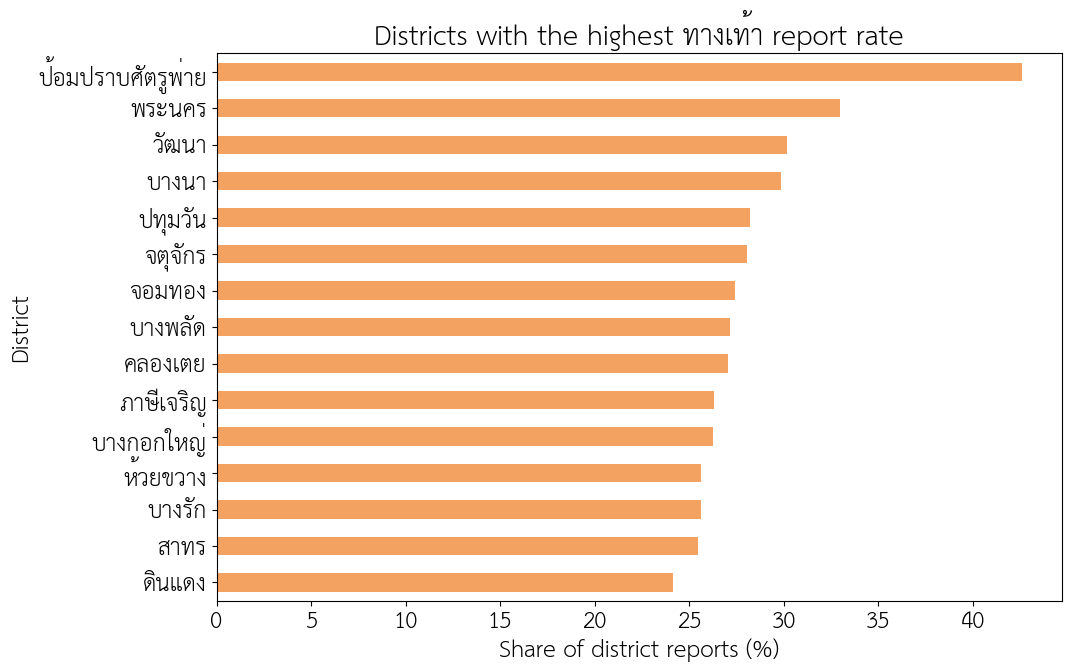

In [16]:
top_districts = comparison.head(15).sort_values("issue_rate_percent")
ax = top_districts["issue_rate_percent"].plot(kind="barh", figsize=(11, 7), color="#F4A261")
ax.set_title(f"Districts with the highest {selected_issue} report rate")
ax.set_xlabel("Share of district reports (%)")
ax.set_ylabel("District")
plt.tight_layout()
plt.show()

## 7. Thai word-frequency visualization

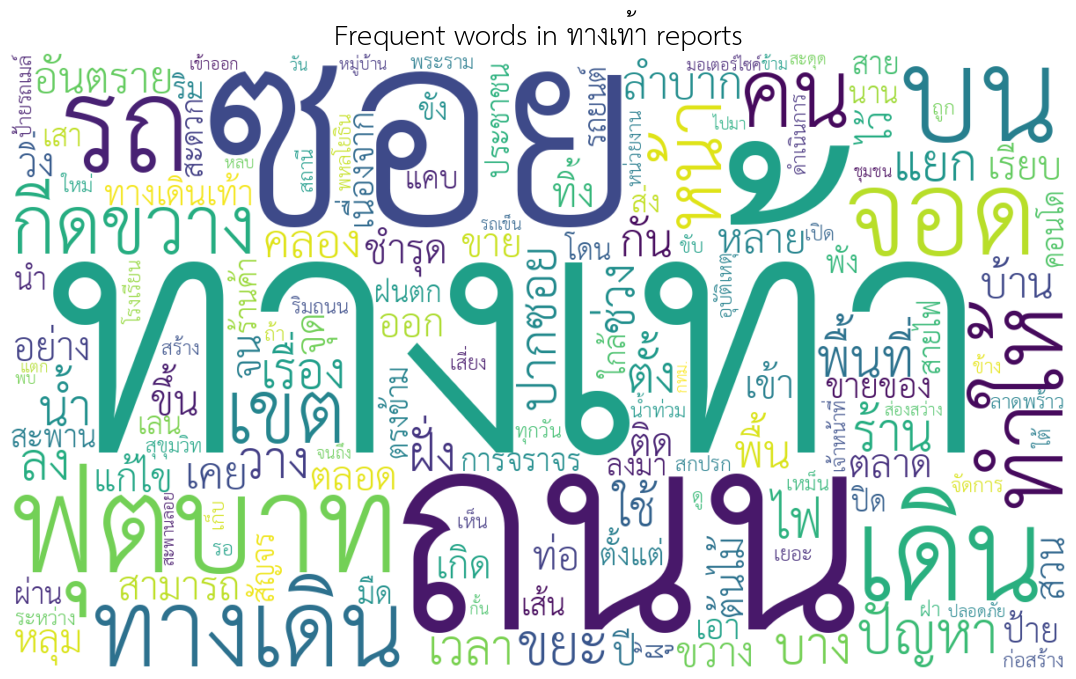

In [17]:
THAI_STOPWORDS = {
    # function words
    "ที่", "และ", "มี", "เป็น", "ให้", "ของ", "ใน", "ไม่", "ได้", "จะ", "กับ",
    "จาก", "บริเวณ", "อยู่", "มาก", "ไป", "มา", "การ", "ความ", "ซึ่ง", "ด้วย",
    "แต่", "หรือ", "ก็", "ว่า", "โดย", "ตาม", "เมื่อ", "แล้ว", "ยัง", "คือ",
    "นี้", "นั้น", "มัน", "ทาง", "ต่อ", "ถึง", "เพราะ", "จึง", "ทั้ง", "อีก",
    "ต้อง", "ควร", "เลย", "แค่", "ตรง", "อยาก", "ทำ", "เพื่อ", "กว่า", "พอ",
    # politeness particles and request phrasing
    "ครับ", "ค่ะ", "คะ", "นะ", "นะคะ", "นะครับ", "หน่อย", "ขอบคุณ", "รบกวน",
    "ช่วย", "ขอ", "กรุณา", "แจ้ง", "เรียน", "ผม", "ดิฉัน", "หนู",
}

# Note: this list was originally applied only to the word cloud. It is now
# also used by the topic model below — see the comment there for why that
# mattered.


def thai_word_frequencies(text_series):
    tokens = []
    for text in text_series.dropna().astype(str):
        tokens.extend(word_tokenize(text, engine="newmm", keep_whitespace=False))
    return Counter(
        token.strip()
        for token in tokens
        if len(token.strip()) > 1 and token.strip() not in THAI_STOPWORDS
    )


selected_comments = classified.loc[classified[selected_issue] == 1, "comment"]
frequencies = thai_word_frequencies(selected_comments)

wordcloud = WordCloud(
    font_path=font_path,
    width=1200,
    height=700,
    background_color="white",
    colormap="viridis",
    max_words=150,
    collocations=False,
).generate_from_frequencies(frequencies)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.title(f"Frequent words in {selected_issue} reports")
plt.axis("off")
plt.show()

## 8. Unsupervised topic discovery

Keyword rules only find issues someone thought to list. Clustering is used to
surface themes the dictionary misses — and, given the recall figures above, to
find the vocabulary those rules are failing on.

### A first attempt that did not work

The initial version vectorised raw comments as character n-grams (3–5,
`char_wb`). Character n-grams are appealing for Thai because they sidestep
word-boundary detection entirely.

The result was unusable. Two clusters absorbed 48% of all reports, and their
defining n-grams were `ค่ะ`, `ครับ`, `ที่`, `ให้`, `ไม่` — politeness particles
and function words. A third cluster keyed on `ลาดพร้าว`, a place name. The
model had grouped reports by how politely they were written and where they were
sent from, not by what they were about. Cluster descriptions also came back as
fragments like `างเท้`, which no stakeholder can read.

### What was changed

Comments are now tokenised with PyThaiNLP's `newmm` engine, filtered through
the stopword list above, and vectorised as word unigrams and bigrams. This
trades the tokeniser-independence of character n-grams for two things worth
more here: clusters driven by content rather than register, and cluster labels
made of real words.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score


def thai_tokens(text):
    """Tokenise with newmm, drop stopwords, punctuation and single characters."""
    tokens = word_tokenize(str(text), engine="newmm", keep_whitespace=False)
    return [
        t.strip() for t in tokens
        if len(t.strip()) > 1
        and t.strip() not in THAI_STOPWORDS
        and not t.strip().isdigit()
    ]


vectorizer = TfidfVectorizer(
    tokenizer=thai_tokens,
    preprocessor=lambda x: x,
    token_pattern=None,
    ngram_range=(1, 2),
    min_df=10,
    max_df=0.5,        # a term in over half the corpus separates nothing
    max_features=12_000,
    sublinear_tf=True,
)

tfidf = vectorizer.fit_transform(classified["comment"])
print(f"TF-IDF matrix: {tfidf.shape}")

TF-IDF matrix: (20730, 7241)


In [19]:
# Choosing the number of clusters.
# Silhouette on sparse high-dimensional text is weak, so it is read as a
# rough guide alongside cluster balance — a k that dumps most reports into
# one cluster is not useful regardless of its score.
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    tfidf.shape[0], size=min(5_000, tfidf.shape[0]), replace=False
)
sample = tfidf[sample_idx]

rows = []
for k in [8, 10, 12, 15, 20]:
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE,
                         batch_size=1_024, n_init=10)
    labels = km.fit_predict(tfidf)
    sizes = pd.Series(labels).value_counts(normalize=True)
    rows.append({
        "k": k,
        "silhouette": silhouette_score(sample, labels[sample_idx]),
        "largest_cluster_share": sizes.max(),
        "smallest_cluster_share": sizes.min(),
    })

k_table = pd.DataFrame(rows).set_index("k")
display(k_table.round(3))

,silhouette,largest_cluster_share,smallest_cluster_share
k,,,
8,0.019,0.558,0.008
10,0.018,0.489,0.010
12,0.016,0.422,0.011
15,-0.017,0.991,0.000
20,-0.015,0.647,0.000


In [20]:
N_CLUSTERS = 15

cluster_model = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    batch_size=1_024,
    n_init=10,
)
classified["topic_cluster"] = cluster_model.fit_predict(tfidf)

sizes = classified["topic_cluster"].value_counts(normalize=True)
print(f"Largest cluster holds {sizes.max():.1%} of reports "
      f"(was 27.9% politeness-driven before the change).")
display(classified["topic_cluster"].value_counts().sort_index().to_frame("reports"))

Largest cluster holds 99.1% of reports (was 27.9% politeness-driven before the change).


,reports
topic_cluster,
0,4
1,1
2,4
3,1
4,3
5,1
6,20543
7,82
8,82


In [21]:
feature_names = np.array(vectorizer.get_feature_names_out())
rows = []

for cluster_id, center in enumerate(cluster_model.cluster_centers_):
    top_terms = feature_names[center.argsort()[-10:][::-1]]
    members = classified["topic_cluster"] == cluster_id
    rows.append({
        "cluster": cluster_id,
        "reports": int(members.sum()),
        "share": members.mean(),
        # How many of this cluster's reports the keyword rules already cover.
        # A cluster with low coverage is a gap in the dictionary.
        "rule_coverage": (
            classified.loc[members, "classified_issue_count"] > 0
        ).mean(),
        "top_terms": ", ".join(top_terms),
    })

cluster_summary = (
    pd.DataFrame(rows).sort_values("reports", ascending=False).set_index("cluster")
)
display(cluster_summary.round(3))

gaps = cluster_summary[cluster_summary["rule_coverage"] < 0.5]
if len(gaps):
    print("Clusters the keyword dictionary largely misses (coverage < 50%):")
    for cid, row in gaps.iterrows():
        print(f"  cluster {cid}: {row['reports']:,} reports, "
              f"coverage {row['rule_coverage']:.0%} — {row['top_terms'][:80]}")
    print("\nThese are the candidates for new keyword rules.")
else:
    print("Every cluster is at least 50% covered by the existing rules.")

,reports,share,rule_coverage,top_terms
cluster,,,,
6,20543,0.991,0.646,"ถนน, ซอย, ทางเท้า, รถ, ไฟ, ขยะ, จอด, บน, ปัญหา..."
8,82,0.004,0.000,"ถนน, ที่จอดรถ, ที่จอดรถ ลูกบ้าน, ที่จะ, ที่จะ ..."
7,82,0.004,0.988,"ไฟ ส่องสว่าง, ส่องสว่าง, ไฟ, ส่องสว่าง ติด, ส่..."
2,4,0.000,1.000,"ต้นไม้ ออก, ต้นไม้, ล้ม หลาย, ตอ, หลาย คน, สะด..."
0,4,0.000,0.750,"ทรุดตัว, ทางเท้า, คอสะพาน, แผ่น ปูน, แผ่น, ปูน..."
4,3,0.000,0.000,"วิดีโอ, ตลอด เส้นทาง, กล้อง, เส้นทาง, ตลอด, หน..."
12,2,0.000,1.000,"ฉิมพลี, ชาวบ้าน เดิน, มีทาง ระบาย, สูง ถนน, ขั..."
13,2,0.000,1.000,"ประชาชน สามารถ, สำนัก เขต, เกิน เมตร, ซอย กาญจ..."
11,2,0.000,1.000,"แตก ทำให้, เดิน ขา, ท่อระบายน้ำ แตก, ส่งกลิ่น ..."


Clusters the keyword dictionary largely misses (coverage < 50%):
  cluster 8: 82 reports, coverage 0% — ถนน, ที่จอดรถ, ที่จอดรถ ลูกบ้าน, ที่จะ, ที่จะ ข้าม, ที่จะ ออก, ที่จะ เกิด, ที่จะ
  cluster 4: 3 reports, coverage 0% — วิดีโอ, ตลอด เส้นทาง, กล้อง, เส้นทาง, ตลอด, หน้า, รถ, ที่จะ เลี้ยว, ที่จะ เดิน, 
  cluster 3: 1 reports, coverage 0% — ธุรกิจ, คอนโด, ท่าน ผู้ว่าฯ, ติดๆ, ลูกบ้าน, ผู้ว่าฯ, บัง, มากขึ้น, ผลกระทบ, เจ้า
  cluster 5: 1 reports, coverage 0% — รามอินทรา, นวลจันทร์, ถนน รามอินทรา, เขต บึง, บึง กุ่ม, กุ่ม, ซอย รามอินทรา, แยก
  cluster 10: 1 reports, coverage 0% — ถ้า รถ, เดินทาง ลำบาก, ทุกวันนี้, จริงๆ, เดินทาง, ถ้า, ลำบาก, รถ, ที่จะ เลี้ยวซ้

These are the candidates for new keyword rules.


In [22]:
def show_cluster_examples(cluster_id, n=6):
    """Read actual reports from a cluster. Term lists are suggestive;
    the reports are what confirm what a cluster is really about."""
    columns = [c for c in ["district", "comment"] if c in classified.columns]
    sample = classified.loc[classified["topic_cluster"] == cluster_id, columns]
    return sample.head(n)


# cluster_summary is indexed by cluster id and sorted by size
largest_cluster = int(cluster_summary.index[0])

print(f"Cluster {largest_cluster} — "
      f"{cluster_summary.loc[largest_cluster, 'reports']:,} reports, "
      f"rule coverage {cluster_summary.loc[largest_cluster, 'rule_coverage']:.0%}")
print(f"Top terms: {cluster_summary.loc[largest_cluster, 'top_terms']}\n")
display(show_cluster_examples(largest_cluster))

Cluster 6 — 20,543 reports, rule coverage 65%
Top terms: ถนน, ซอย, ทางเท้า, รถ, ไฟ, ขยะ, จอด, บน, ปัญหา, เขต



,district,comment
0,สายไหม,กันที่จอดรถ
1,บางพลัด,ผักตบชวาขึ้นในคลองจำนวนมาก ทำให้การระบายน้ำไม่...
2,สาทร,1. รถหามเร่ รถขายของบนถนน
3,ห้วยขวาง,สน. พหลโยธิน เค้าจะรื้อถอนไหมครับ เพราะทางเท้า...
4,สายไหม,จอดส่งของ
5,วัฒนา,หน่วยงานไม่เก็บขยะ


In [23]:
# The cluster the keyword rules cover least is the more useful one to read:
# it is where the dictionary is blind.
weakest = int(cluster_summary["rule_coverage"].idxmin())

print(f"Cluster {weakest} — lowest rule coverage "
      f"({cluster_summary.loc[weakest, 'rule_coverage']:.0%}), "
      f"{cluster_summary.loc[weakest, 'reports']:,} reports")
print(f"Top terms: {cluster_summary.loc[weakest, 'top_terms']}\n")
display(show_cluster_examples(weakest))

print(
    "\nReading these reports is how new keyword rules get written. "
    "Terms appearing here that are absent from ISSUE_KEYWORDS are the "
    "candidates to add, after which section 5b can be re-run to confirm "
    "recall improved."
)

Cluster 8 — lowest rule coverage (0%), 82 reports
Top terms: ถนน, ที่จอดรถ, ที่จอดรถ ลูกบ้าน, ที่จะ, ที่จะ ข้าม, ที่จะ ออก, ที่จะ เกิด, ที่จะ เข้า, ที่จะ เดิน, ที่จะ เลี้ยว



,district,comment
87,บึงกุ่ม,ถนน
806,สะพานสูง,ถนน
1148,บางบอน,ถนน
1186,คลองสาน,ถนน
1236,วัฒนา,ถนน
1419,บางซื่อ,ถนน



Reading these reports is how new keyword rules get written. Terms appearing here that are absent from ISSUE_KEYWORDS are the candidates to add, after which section 5b can be re-run to confirm recall improved.


## 8b. Resolution status

Two columns describe what happened after a report was filed. `state` records
the workflow stage; `after_photo` holds a completion photograph, present on
only part of the data.

Reporting volume alone tells a city team where complaints come from. Volume
paired with resolution rate tells them where complaints come from *and go
unanswered*, which is the more useful pair for allocating capacity.

In [24]:
display(analysis_data["state"].value_counts().to_frame("reports"))

has_after = analysis_data["after_photo"].notna() & (
    analysis_data["after_photo"].astype(str).str.strip() != ""
)
print(f"Reports with a completion photo: {has_after.sum():,} "
      f"({has_after.mean():.1%})")

,reports
state,
ส่งเรื่องแล้ว,8934
รอรับเรื่อง,8363
เสร็จสิ้น,3433


Reports with a completion photo: 2,708 (13.1%)


In [25]:
classified["has_after_photo"] = (
    classified["after_photo"].notna()
    & (classified["after_photo"].astype(str).str.strip() != "")
).astype(int)

resolution_by_district = (
    classified[classified["district"].isin(eligible_districts)]
    .groupby("district")
    .agg(reports=("comment", "size"),
         completion_photo_rate=("has_after_photo", "mean"))
    .sort_values("completion_photo_rate")
)

print("Lowest completion-photo rate among districts with "
      f"at least {MIN_DISTRICT_REPORTS} reports:")
display(resolution_by_district.head(10).round(3))
print("\nHighest:")
display(resolution_by_district.tail(5).round(3))

Lowest completion-photo rate among districts with at least 100 reports:


,reports,completion_photo_rate
district,,
ดินแดง,539,0.000
ยานนาวา,352,0.000
คลองเตย,451,0.004
บางกอกน้อย,516,0.017
ปทุมวัน,510,0.039
หนองจอก,330,0.039
หนองแขม,220,0.041
ราชเทวี,609,0.048
ห้วยขวาง,617,0.050



Highest:


,reports,completion_photo_rate
district,,
ลาดพร้าว,412,0.248
มีนบุรี,346,0.260
บางเขน,655,0.266
ประเวศ,601,0.278
พระนคร,282,0.358


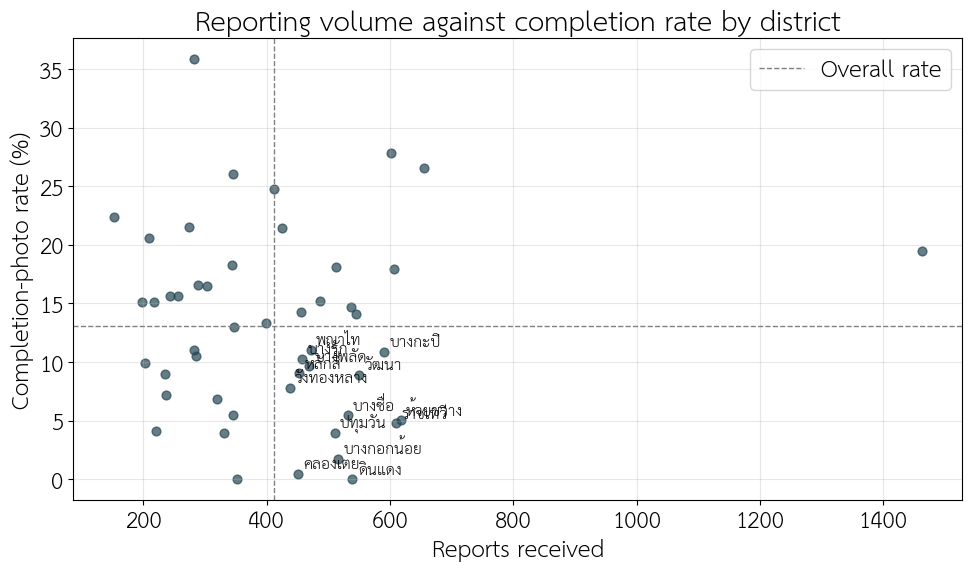

14 districts sit above median volume and below the overall completion rate. Those are the ones worth asking about first.


In [26]:
# Volume against resolution: the quadrant a city team would act on is
# high volume with low completion.
plot_data = resolution_by_district.reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_data["reports"], plot_data["completion_photo_rate"] * 100,
           s=40, alpha=0.7, color="#264653")
ax.axhline(classified["has_after_photo"].mean() * 100, ls="--", lw=1,
           color="grey", label="Overall rate")
ax.axvline(plot_data["reports"].median(), ls="--", lw=1, color="grey")
ax.set_xlabel("Reports received")
ax.set_ylabel("Completion-photo rate (%)")
ax.set_title("Reporting volume against completion rate by district")
ax.legend()
ax.grid(alpha=0.3)

# Label the districts in the high-volume, low-completion quadrant
median_reports = plot_data["reports"].median()
overall_rate = classified["has_after_photo"].mean()
flagged = plot_data[
    (plot_data["reports"] > median_reports)
    & (plot_data["completion_photo_rate"] < overall_rate)
]
for _, row in flagged.iterrows():
    ax.annotate(row["district"], (row["reports"], row["completion_photo_rate"] * 100),
                fontsize=11, xytext=(4, 4), textcoords="offset points")

plt.tight_layout()
plt.show()

print(f"{len(flagged)} districts sit above median volume and below the overall "
      "completion rate. Those are the ones worth asking about first.")

In [27]:
# Completion rate by issue category — which problem types stall
issue_resolution = pd.DataFrame({
    "reports": [int(classified[c].sum()) for c in issue_columns],
    "completion_photo_rate": [
        classified.loc[classified[c] == 1, "has_after_photo"].mean()
        for c in issue_columns
    ],
}, index=issue_columns).sort_values("completion_photo_rate")

display(issue_resolution.round(3))
print(
    "\nCaveat: a missing completion photo is not proof a report was ignored. "
    "It may reflect uneven documentation practice between districts rather "
    "than uneven service. Treated here as a signal worth investigating, not "
    "a performance measure."
)

,reports,completion_photo_rate
ทางข้าม,750,0.065
แสงสว่าง,1560,0.073
ความปลอดภัย,1717,0.105
ถนน,1514,0.108
สัตว์,858,0.113
สายไฟ/ความเป็นระเบียบ,917,0.121
จราจร,2257,0.126
น้ำท่วม/ระบายน้ำ,2091,0.129
ทางเท้า,4351,0.167
ต้นไม้,683,0.195



Caveat: a missing completion photo is not proof a report was ignored. It may reflect uneven documentation practice between districts rather than uneven service. Treated here as a signal worth investigating, not a performance measure.


## 9. Automated analytical summary

In [28]:
top_issue = issue_summary.index[0]
top_issue_share = issue_summary.loc[top_issue, "share_percent"]
highest_volume_district = district_total.idxmax()
highest_volume = district_total.max()
top_rate_district = district_issue_rate[top_issue].idxmax()
top_rate = district_issue_rate.loc[top_rate_district, top_issue]

print("KEY FINDINGS")
print("-" * 60)
print(f"1. Most frequently identified issue: {top_issue} ({top_issue_share:.2f}% of reports).")
print(f"2. District with the largest reporting volume: {highest_volume_district} ({highest_volume:,} reports).")
print(f"3. Highest {top_issue} rate among eligible districts: {top_rate_district} ({top_rate:.2f}%).")
print(f"4. Rule-based issue coverage: {coverage:.2f}% of reports.")
print(f"5. Topic discovery grouped the comments into {N_CLUSTERS} exploratory clusters.")

KEY FINDINGS
------------------------------------------------------------
1. Most frequently identified issue: ทางเท้า (20.99% of reports).
2. District with the largest reporting volume: จตุจักร (1,462 reports).
3. Highest ทางเท้า rate among eligible districts: ป้อมปราบศัตรูพ่าย (42.58%).
4. Rule-based issue coverage: 64.46% of reports.
5. Topic discovery grouped the comments into 15 exploratory clusters.


## 10. Business interpretation and recommendations

- **Prioritise on volume and rate together.** Volume indicates workload; a high
  within-district rate indicates a concentrated local problem. The two point at
  different districts.
- **Pair both with resolution rate.** High volume and low completion is the
  quadrant that needs capacity, not just attention.
- **Grow the keyword dictionary from the clusters.** The clusters with low rule
  coverage identify exactly which vocabulary the rules are missing, and the
  recall figures in section 5b show which categories need it most.
- **Route categories to the responsible operational teams** and track ageing of
  unresolved reports by district.
- **Combine with population, road length, rainfall and service-capacity data**
  before making resource-allocation decisions. Report counts alone conflate a
  problem with a population's willingness to report it.

## Limitations

- **The extract covers 19 days: 25 May to 12 June 2022.** This is the onset of
  the Bangkok rainy season, so the 10.1% flooding share almost certainly
  overstates the annual figure. No seasonal claim can be made from this window,
  and no trend either — a 19-day series cannot separate a structural problem
  from a single storm.
- **Reports represent platform users**, who are not a random sample of Bangkok
  residents. District volume measures reporting propensity as much as it
  measures problems.
- **Keyword rules miss synonyms, misspellings, sarcasm and context**, and cover
  64.5% of reports. Section 5b quantifies the error against platform labels
  where a counterpart category exists.
- **Categories overlap by design** — a report may mention several issues — so
  the category shares sum to more than 100%.
- **Completion photos are an imperfect proxy for resolution.** Absence may
  reflect documentation practice rather than inaction.
- **16.2% of comments repeat text seen elsewhere in the data**, which may
  indicate duplicate submissions of the same incident.
- **Cluster labels describe term co-occurrence, not verified topics.** They are
  a starting point for reading reports, not a classification.

## Next Steps

- Obtain a full-year extract to separate seasonal effects from structural ones.
- Normalise report counts by district population and road length.
- Expand the keyword dictionary from the low-coverage clusters, then re-score
  against platform labels to confirm recall improved.
- Measure time-to-resolution where timestamps allow, rather than using photo
  presence as a proxy.
- Train a supervised classifier on the platform's own labels and compare it
  against the transparent keyword rules on both accuracy and reviewability.